# Figure results of the study *Alzheimer's Disease Brain Phenotypes are Age-dependent*

This notebook regenerates the **data-driven results figure** of the paper, in the
order they appear in the manuscript.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from scripts.constants import EVALUATION_PATH

---
## Figure 2 — Aging information is necessary for disease detection

We first quantify how much phenotypic information the three VAE representations
(*age-invariant*, *age-agnostic*, *age-aware*) encode, how well they detect disease,
and how the disease structure is organised in latent space.

### Figure 2D — Phenotype estimation & reconstruction error

Bar plots of **age estimation** (MAE, correlation coefficient) and **image reconstruction** (MSE) on the test set of
the General-population dataset, with a shuffled-label / mean-image **Random** baseline.
Values are the mean and the bars the standard deviation of a bootstrapped distribution
(N = 1000); significance between two distributions is the proportion of lower values.
This mirrors the README command
`python plot.py -b -t age_at_scan reconstruction_error -d general -c age_invariant/e100 age_agnostic/e100 age_aware/e100 baseline`.

Age-agnostic age_at_scan MAE: 4.2585 -- std: 0.1101
Age-agnostic age_at_scan Correlation: 0.8452 (p: 0.0000)
Age-aware age_at_scan MAE: 2.9231 -- std: 0.0727
Age-aware age_at_scan Correlation: 0.9327 (p: 0.0000)
Age-invariant age_at_scan MAE: 7.6612 -- std: 0.2132
Age-invariant age_at_scan Correlation: 0.2311 (p: 0.0000)
Random age_at_scan MAE: 11.1620 -- std: 0.3650
Random age_at_scan Correlation: 0.0006 (p: 0.5000)
Age-agnostic reconstruction_error MSE: 0.2376 -- std: 0.0418
Age-aware reconstruction_error MSE: 0.3166 -- std: 0.0580
Age-invariant reconstruction_error MSE: 0.3316 -- std: 0.0547
Random reconstruction_error MSE: 0.4668 -- std: 0.0950
Saved bar plots to evaluation/general/test/bar_plots.png


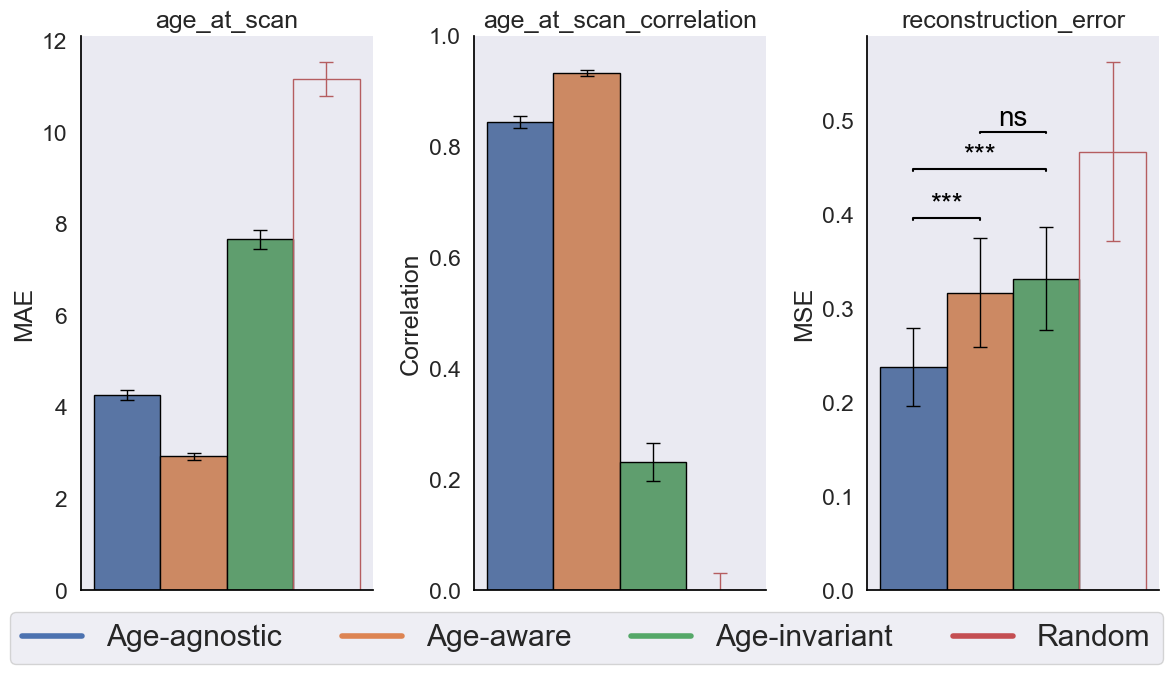

In [4]:
from scripts.utils import load_predictions, compute_metrics
from plot import plot_bar_plots

results_path = Path(EVALUATION_PATH, 'general', 'test')
cfgs    = ['age_agnostic', 'age_aware', 'age_invariant', 'baseline']
targets = ['age_at_scan', 'reconstruction_error']

# load_predictions reads each <cfg>/e100/<target>_predictions.csv and renames the cfgs
labels_predictions, evaluated_cfgs = load_predictions(targets, cfgs, results_path)
# compute_metrics bootstraps MAE / correlation / MSE across the saved prediction runs
metrics = compute_metrics(labels_predictions, targets, evaluated_cfgs)

fig = plot_bar_plots(metrics, evaluated_cfgs, results_path)
plt.show()

### Figure 2E — Disease-detection ROC-AUC

Violin plots of the bootstrapped ROC-AUC distributions for the three diagnostic tasks
— **AD vs HC** (`dvh`), **AD vs MCI** (`dvp`) and **MCI vs HC** (`hvp`) — using the three
brain representations and the brain-age-gap (**BAG**) logistic-regression baseline.
Asterisks mark significance against *age-invariant*; the dashed line is chance (0.5).
Mirrors `python plot.py -d diseased_balanced -c age_invariant/e100 age_agnostic/e100 age_aware/e100 bag/e100`.

**********ROC-AUCs values**********
DVH:
Age-agnostic dvh AUC: 0.8532 IQR: 0.0338
Age-aware dvh AUC: 0.8435 IQR: 0.0344
Age-invariant dvh AUC: 0.7710 IQR: 0.0428
BAG dvh AUC: 0.7185 IQR: 0.0471
DVP:
Age-agnostic dvp AUC: 0.7314 IQR: 0.0456
Age-aware dvp AUC: 0.7088 IQR: 0.0468
Age-invariant dvp AUC: 0.6478 IQR: 0.0486
BAG dvp AUC: 0.6679 IQR: 0.0474
HVP:
Age-agnostic hvp AUC: 0.6746 IQR: 0.0297
Age-aware hvp AUC: 0.6529 IQR: 0.0287
Age-invariant hvp AUC: 0.5955 IQR: 0.0311
BAG hvp AUC: 0.6170 IQR: 0.0303
Saved plot to evaluation/diseased_balanced/test/roc_aucs.png


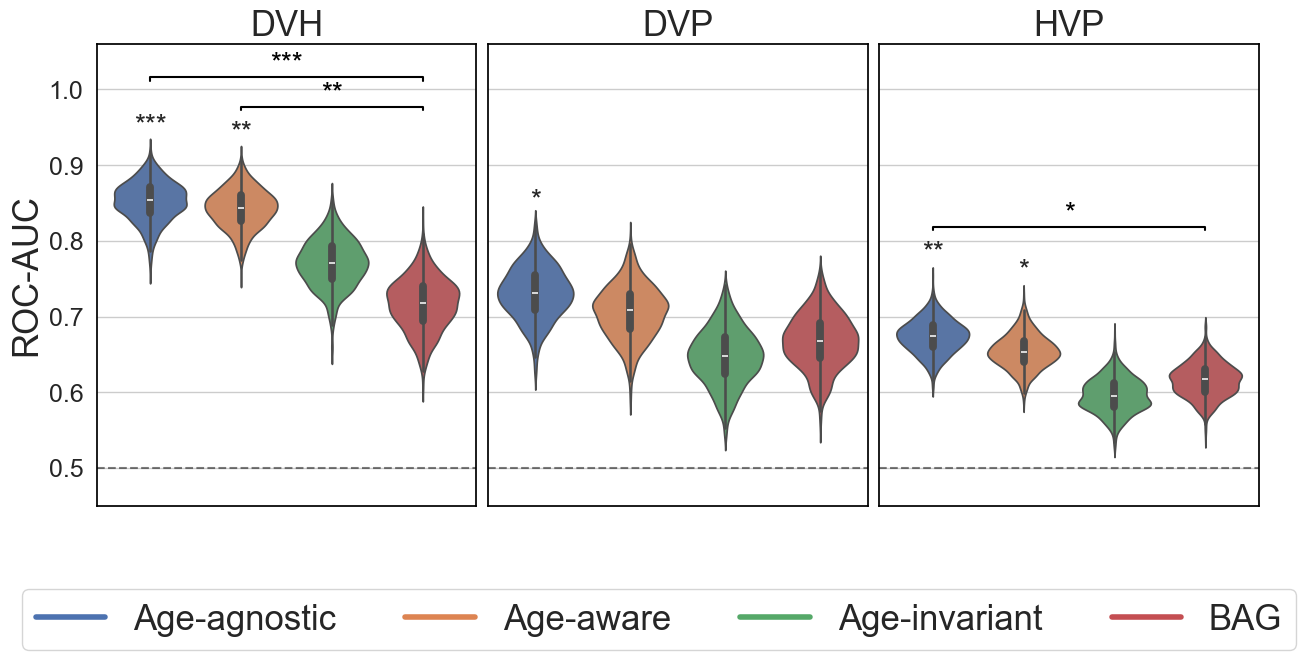

In [8]:
from scripts.utils import get_age_windows
from plot import build_roc_curves, plot_data

results_path = Path(EVALUATION_PATH, 'diseased_balanced', 'test')
cfgs    = ['age_agnostic', 'age_aware', 'age_invariant', 'bag']
targets = ['dvh', 'dvp', 'hvp']

labels_predictions, evaluated_cfgs = load_predictions(targets, cfgs, results_path)
age_windows_ranges = get_age_windows(labels_predictions, targets, evaluated_cfgs, 0)

roc_curves = build_roc_curves(labels_predictions, targets, evaluated_cfgs, age_windows=0)
fig = plot_data(roc_curves, evaluated_cfgs, '', 'ROC-AUC', (0.45, 1.06), False, 25,
                results_path / 'roc_aucs.png', age_windows_ranges)
plt.show()

### Figure 2F — PCA of the latent representations

First two principal components of the *age-aware* and *age-invariant* representations on the
matched (balanced) Diseased test set. Marker transparency encodes the individual's age.
The full command is
`python test.py e100/last --cfg <cfg> --dataset diseased_balanced --label dx --manifold pca`

Seed set to 42


--- age_aware ---


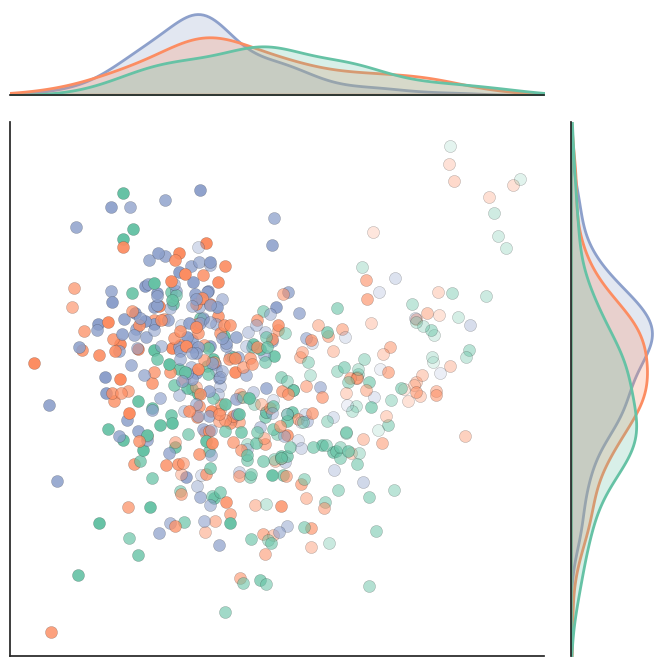

Figure saved at evaluation/diseased_balanced/test/age_aware/e100/latents_pca_dx.png


<Figure size 640x480 with 0 Axes>

Seed set to 42


--- age_invariant ---


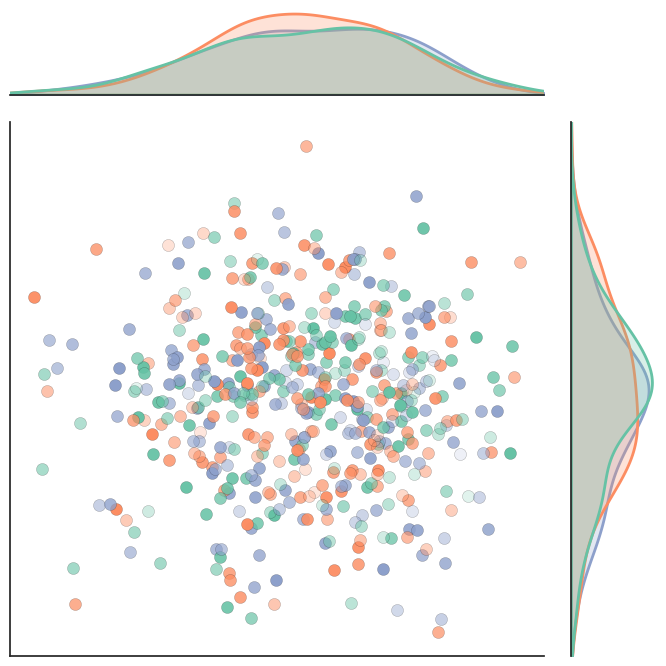

Figure saved at evaluation/diseased_balanced/test/age_invariant/e100/latents_pca_dx.png


<Figure size 640x480 with 0 Axes>

In [9]:
from test import plot_embeddings

for cfg in ['age_aware', 'age_invariant']:
    emb_path = Path(EVALUATION_PATH, 'diseased_balanced', 'test', cfg, 'e100')
    subjects_df = pd.read_pickle(emb_path / 'subjects_embeddings.pkl')
    print(f'--- {cfg} ---')
    fig = plot_embeddings(subjects_df, 'pca', 'dx', emb_path, color_by=None)
    plt.show()

---
## Figure 3 — Brain aging unfolds along multiple dimensions

Using the *age-invariant* conditional decoder, young/old subjects are re-aged, the relative
reconstruction differences are computed and warped to MNI space, and these aging-difference
maps are decomposed with PCA and NMF.

### Figure 3D — NMF component weights in AD vs HC

Re-aged AD patients and healthy controls are projected onto the three aging NMF components; the
box plots compare the normalised component weights, with Mann-Whitney significance stars.
Component 3 (temporal atrophy) is heavier in AD, component 2 lighter — matching known early AD
neurodegeneration. Mirrors `python aging_decomposition.py --nmf`.

Loading existing NMF components from aging_decomposition/3_components...
Reconstructing AD and HC age changes using NMF components...
Saved boxplot comparison to aging_decomposition/nmf_boxplot_comparison.png

Component 1:
  Alzheimer's Disease: mean=0.191, std=0.128
  Healthy Controls: mean=0.187, std=0.120
  Mann-Whitney U test: U=42395.00, p=0.8449
  Effect size (Cohen's d): 0.027

Component 2:
  Alzheimer's Disease: mean=0.561, std=0.135
  Healthy Controls: mean=0.601, std=0.130
  Mann-Whitney U test: U=34524.00, p=0.0002
  Effect size (Cohen's d): -0.300

Component 3:
  Alzheimer's Disease: mean=0.248, std=0.129
  Healthy Controls: mean=0.212, std=0.119
  Mann-Whitney U test: U=48598.00, p=0.0011
  Effect size (Cohen's d): 0.294


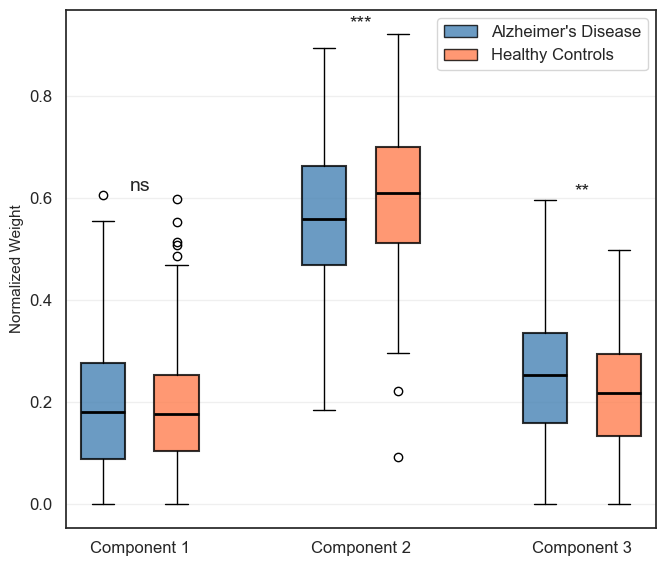

In [12]:
from aging_decomposition import run_nmf_analysis

fig = run_nmf_analysis(Path('aging_decomposition'), n_components=3)
plt.show()

---
## Figure 4 — Transfer learning and representational similarity analysis

Models pretrained on age, sex and BMI (plus a non-pretrained baseline) are fine-tuned for the
three diagnostic tasks. We compare their internal representations layer-by-layer using RSA on the
precomputed Representational Dissimilarity Matrices (`pretrain_exp/results/<task>/rdms.pkl`).
Mirrors `python rsa_analysis.py`.

The next cell computes all bootstrapped RDM comparisons once; Figures 4C and 4D reuse the result.

In [2]:

from pretrain_exp.rsa import compare_models

tasks   = ['ad_vs_hc', 'ad_vs_mci', 'mci_vs_hc']
models  = ['age', 'sex', 'bmi', 'none']
layers  = ['conv0', 'conv1', 'conv2', 'conv3', 'conv4', 'conv5']
layer   = 'conv5'
n_iters = 1000
rdms_path = Path('pretrain_exp', 'results')

comparisons_dict = compare_models(tasks, models, layers, rdms_path, n_iters, random_state=42)

### Figure 4C — Representational similarity across layers

For each diagnostic task, the distribution of pairwise similarities between the pretrained
(age / sex / BMI) models at every convolutional layer. The models are highly similar in the
early layers (a shared, brain-like representation) and diverge in the deeper layers.

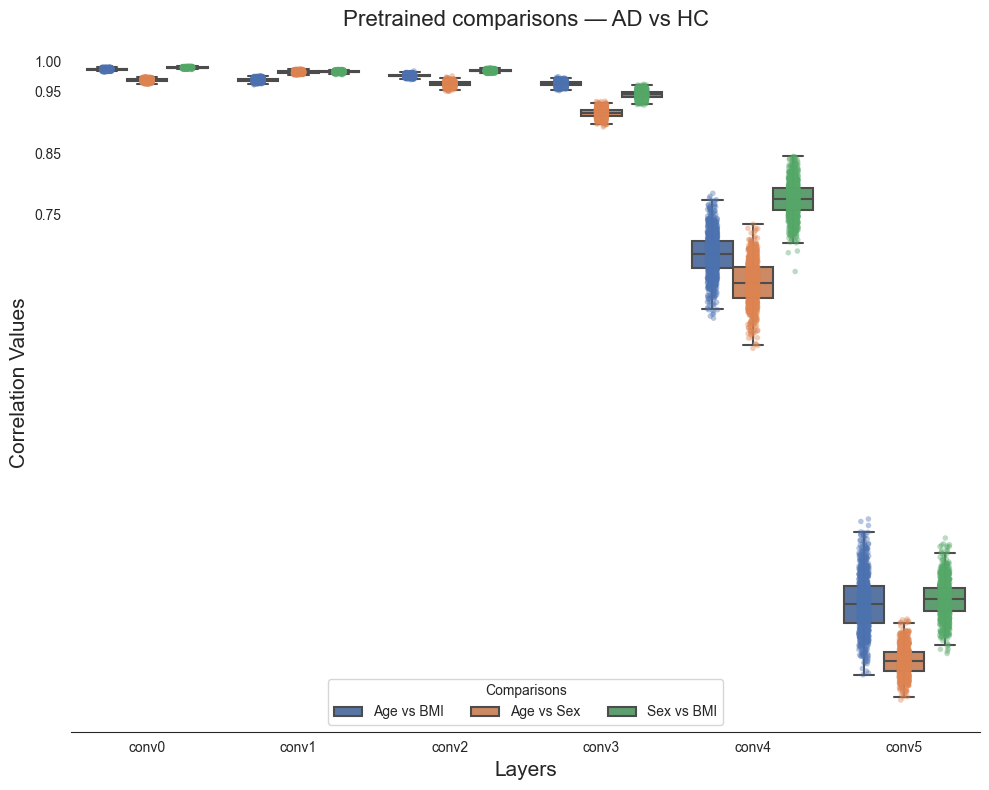

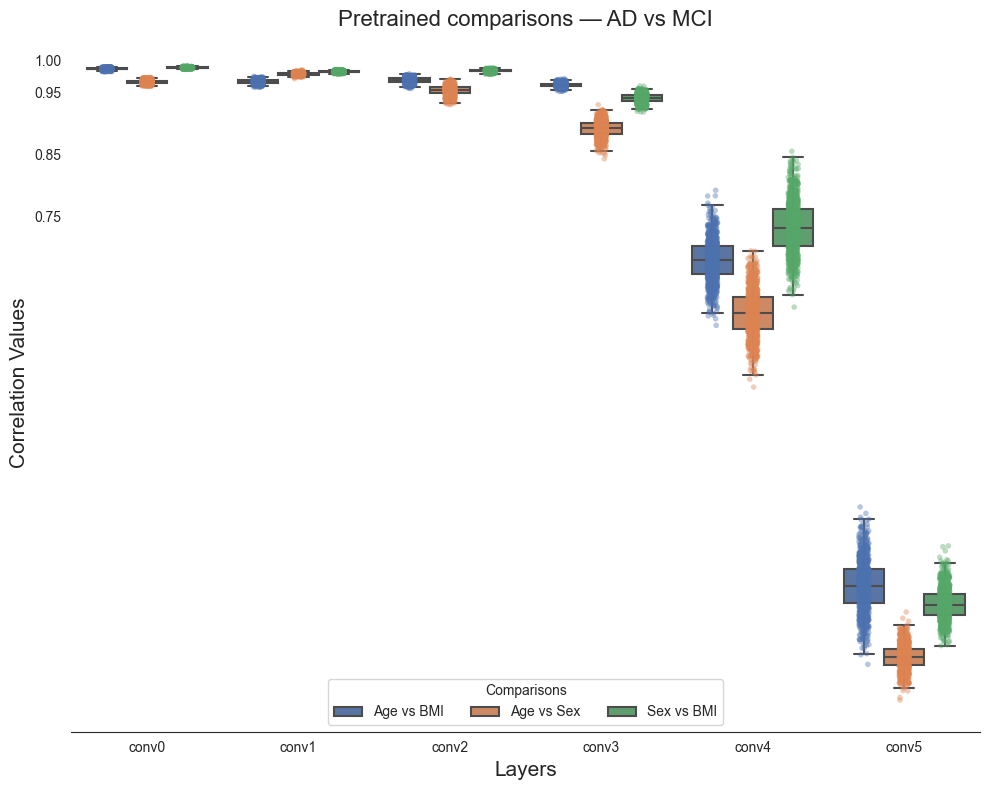

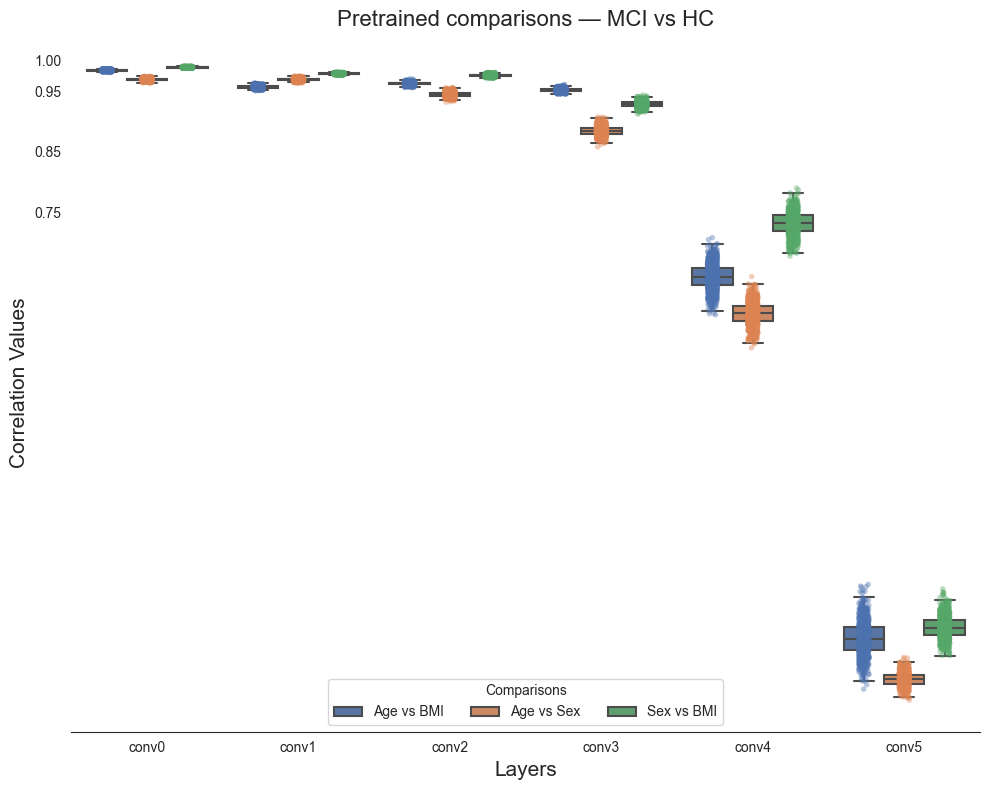

In [3]:
from rsa_analysis import plot_model_comparisons, parse_task_name

for task in tasks:
    fig = plot_model_comparisons(
        comparisons_dict[task], model_type='pretrained', legend=True,
        title=f'Pretrained comparisons — {parse_task_name(task)}')
    plt.show()

### Figure 4D — Representational shift after fine-tuning

How much each pretrained representation moves in the last convolutional layer after fine-tuning,
per diagnostic task. The grid shows the similarity densities before (blue) and after (orange)
fine-tuning for each pretrained modality; the accompanying error-bar plot quantifies the mean
shift. The age-pretrained model shifts the least — its representations are already closest to
the disease-relevant structure.

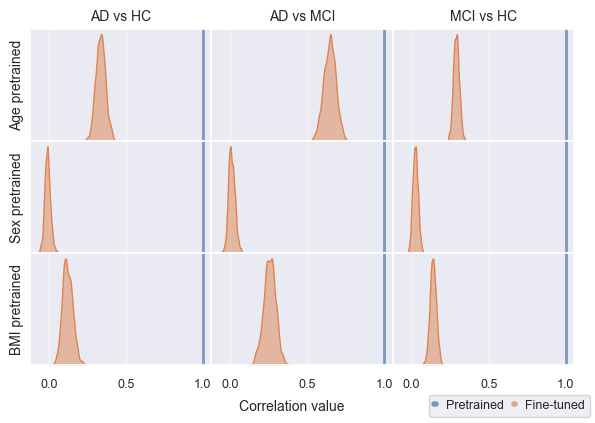

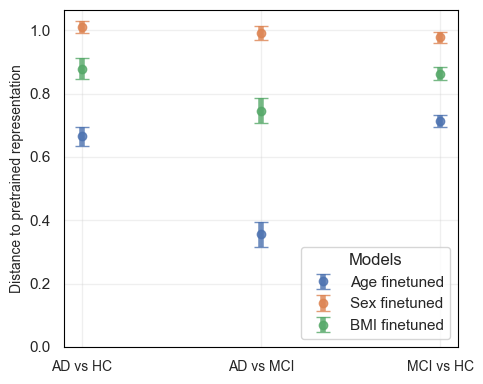

In [4]:
from rsa_analysis import plot_rsa_histogram_grid, plot_representational_shifts

# Similarity densities: pretrained vs fine-tuned, last conv layer (rows=models, cols=tasks)
fig = plot_rsa_histogram_grid(comparisons_dict, layer=layer, tasks=tasks, only_diagonal=True)
plt.show()

# Quantified representational shift per model and task
representational_shifts = {}
for task in tasks:
    for model in comparisons_dict[task]:
        if model.endswith('_tl'):
            continue
        name = model.split('_')[0]
        representational_shifts.setdefault(name, {})
        finetuned = name + '_tl'
        self_corr = np.array(comparisons_dict[task][model][model][layer])
        ft_corr   = np.array(comparisons_dict[task][model][finetuned][layer])
        shift = np.abs(self_corr - ft_corr)
        representational_shifts[name][task] = [shift.mean(), shift.std()]

fig = plot_representational_shifts(representational_shifts)
plt.show()